In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeStretch, Gain
import random
import torch
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torch.nn.functional as F
import warnings

# Ignoruj wszystkie ostrzeżenia
warnings.filterwarnings('ignore')


In [2]:
from albumentations import Compose as AlbumentationsCompose
from albumentations import ShiftScaleRotate, CoarseDropout, ChannelShuffle
from albumentations.pytorch import ToTensorV2

def apply_augmentations(audio, sample_rate):
    """
    Applies defined augmentation transformations to the audio signal.
    """

    # Define transformations using audiomentations
    augment = Compose([
        AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5), # Add Gaussian noise
        PitchShift(min_semitones=-2, max_semitones=2, p=0.5),           # Change pitch
        TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),                 # Stretch/compress time
        Gain(min_gain_db=-7.0, max_gain_db=7.0, p=0.5),            # Change volume
    ])
    return augment(samples=audio, sample_rate=sample_rate)

def audio_to_mel_spectrogram(audio, sample_rate, n_fft, hop_length, n_mels):
    """
    Transforms an audio signal into a Mel-spectrogram.
    """
    # Ensure audio is float32, which is standard for librosa
    audio = audio.astype(np.float32)

    # Compute Mel-spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(
        y=audio,
        sr=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    # Convert to decibel scale (logarithmic)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

    #  Normalization (to 0-1 range)
    mel_spectrogram_norm = (mel_spectrogram_db - mel_spectrogram_db.min()) / \
                          (mel_spectrogram_db.max() - mel_spectrogram_db.min())
    return mel_spectrogram_norm


def augment_spectrogram(spectrogram):
    """
    Applies augmentations directly to the Mel-spectrogram.
    Expects a NumPy array (H, W) or (1, H, W).
    Returns a NumPy array.
    """
    # Albumentations oczekuje obrazu w formacie (H, W, C) lub (H, W) dla grayscale
    # Nasz spektrogram jest (H, W), więc będzie traktowany jako grayscale
    augment_spec = AlbumentationsCompose([
        ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=5, p=0.5), # Przesunięcia, skalowanie, rotacja
        # CoarseDropout (SpecAugment-like) - symuluje blokowanie fragmentów spektrogramu
        CoarseDropout(max_holes=8, max_height=8, max_width=8, fill_value=0, p=0.3),
        # ChannelShuffle może być użyteczne, jeśli spektrogram miałby wiele kanałów (np. RGB),
        # ale dla pojedynczego kanału jest mniej znaczące, chyba że pomyślisz o nim inaczej.
        # Na razie zostawię go jako opcjonalny.
        # ChannelShuffle(p=0.2),
        # Normalize(mean=(0.5,), std=(0.5,)), # Możesz chcieć ponownej normalizacji po augmentacji
    ])

    augmented = augment_spec(image=spectrogram)
    return augmented['image']


In [3]:

SAMPLE_RATE = 22050
DURATION = 4  # Długość segmentu w sekundach
N_SAMPLES = SAMPLE_RATE * DURATION # Number of samples in 4 seconds

N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128

AUDIO_DATA_DIR = 'SoundData/PreparedData'
METADATA_FILE = 'SoundData/Metadata_All_Normalized.csv'

DEFAULT_AUDIO_EXTENSION = '.wav'

# --- Zmodyfikowana definicja klasy WildBoarDataset ---
class WildBoarDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, sample_rate, duration, n_fft, hop_length, n_mels,
                 augment=False, filepath_col='FilePath', label_col='Label'): # DODANY ARGUMENT default_extension

        self.dataframe = dataframe
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.augment = augment
        self.filepath_col = filepath_col
        self.label_col = label_col
        self.target_samples = int(self.duration * self.sample_rate)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        audio_path = self.dataframe.iloc[idx][self.filepath_col]
        label = self.dataframe.iloc[idx][self.label_col]

        try:
            audio, sr = librosa.load(audio_path, sr=self.sample_rate, duration=self.duration)

            # Upewnij się, że audio ma dokładnie odpowiednią długość, jeśli nie, dodaj padding.
            target_samples = int(self.duration * self.sample_rate)
            if len(audio) < target_samples:
                audio = np.pad(audio, (0, target_samples - len(audio)), 'constant')
            elif len(audio) > target_samples:
                audio = audio[:target_samples]

            if self.augment:
                audio = apply_augmentations(audio, self.sample_rate)

            # Konwersja na spektrogram Mel
            mel_spectrogram = audio_to_mel_spectrogram(
                audio, self.sample_rate, self.n_fft, self.hop_length, self.n_mels
            )

            '''# --- Augmentacja SPEKTROGRAMU ---
            if self.augment:
                mel_spectrogram = augment_spectrogram(mel_spectrogram)'''

            mel_spectrogram_tensor = torch.tensor(mel_spectrogram, dtype=torch.float32).unsqueeze(0)

            return mel_spectrogram_tensor, label

        except Exception as e:
             # Zwróć zero tensor i -1 jako etykietę w przypadku błędu
             # Obliczamy oczekiwany kształt dla pustego spektrogramu
             # liczba ramek = floor(duration * sr / hop_length) + 1
             num_frames = int(np.floor(self.duration * self.sample_rate / self.hop_length)) + 1
             print(f"Błąd podczas ładowania lub przetwarzania pliku {audio_path}: {e}")
             return torch.zeros((1, self.n_mels, num_frames), dtype=torch.float32), -1

In [4]:

# --- Konfiguracja ---
# Nazwa pliku z metadanymi pociętych nagrań (segmentów/augmentacji)
METADATA_ALL_NORMALIZED_FILE  = METADATA_FILE

# Nazwy plików CSV zawierających listy oryginalnych nagrań dla każdego zbioru
TRAIN_ORIGINAL_NAMES_FILE = 'train_original_names.csv'
VAL_ORIGINAL_NAMES_FILE = 'val_original_names.csv'
TEST_ORIGINAL_NAMES_FILE = 'test_original_names.csv'

FILENAME_COLUMN  = 'OriginalFileName'
SEGMENT_LABEL_COLUMN = 'Label'
SEGMENT_QUALITY_COLUMN = 'Quality'

# --- 1. Wczytanie list nazw oryginalnych nagrań dla każdego zbioru ---
print("Wczytywanie list nazw oryginalnych nagrań (train/val/test)...")
try:
    train_original_names = pd.read_csv(TRAIN_ORIGINAL_NAMES_FILE)['original_recording_name'].tolist()
    val_original_names = pd.read_csv(VAL_ORIGINAL_NAMES_FILE)['original_recording_name'].tolist()
    test_original_names = pd.read_csv(TEST_ORIGINAL_NAMES_FILE)['original_recording_name'].tolist()
    print("Listy wczytane pomyślnie.")
except FileNotFoundError as e:
    print(f"Błąd: Nie znaleziono jednego z plików z listami oryginalnych nagrań: {e}.")
    train_original_names = []
    val_original_names = []
    test_original_names = []

train_original_set = set(train_original_names)
val_original_set = set(val_original_names)
test_original_set = set(test_original_names)

# --- 2. Wczytanie i przygotowanie metadanych pociętych nagrań ---
print(f"\nWczytywanie metadanych dla pociętych nagrań z pliku: {METADATA_ALL_NORMALIZED_FILE}...")
try:
    df_all_segments = pd.read_csv(METADATA_ALL_NORMALIZED_FILE, sep=';')
    print(f"Pomyślnie wczytano {len(df_all_segments)} próbek z metadanych pociętych nagrań.")
except FileNotFoundError:
    print(f"Błąd: Plik metadanych '{METADATA_ALL_NORMALIZED_FILE}' nie został znaleziony.")
    df_all_segments = []

# Filtrowanie po Quality == 1
initial_filtered_samples = len(df_all_segments)
'''df_filtered_segments = df_all_segments[df_all_segments[SEGMENT_QUALITY_COLUMN] == 1].copy()
print(f"Odrzucono {initial_filtered_samples - len(df_filtered_segments)} próbek z '{SEGMENT_QUALITY_COLUMN}' != 1.")
print(f"Liczba próbek po filtracji jakości: {len(df_filtered_segments)}")'''
df_filtered_segments = df_all_segments

if df_filtered_segments.empty:
    print("Błąd: Brak danych do przetworzenia po filtracji Quality=1. Zakończono.")
else:
    # --- 3. Przypisywanie zbioru na podstawie oryginalnego nagrania ---
    # Dodaj kolumnę do przechowywania nazwy oryginalnego nagrania (bez rozszerzenia)
    df_filtered_segments['original_recording_name'] = df_filtered_segments[FILENAME_COLUMN].apply(
        lambda x: os.path.splitext(x.split('_')[0] if '_' in x else x)[0])
        #TODO this works for current data but can easily fail!

    # Funkcja do określania przynależności do zbioru
    def assign_split(original_name):
        if original_name in train_original_set:
            return 'train'
        elif original_name in val_original_set:
            return 'val'
        elif original_name in test_original_set:
            return 'test'
        else:
            return 'unknown' # Jeśli oryginalny plik nie znajduje się w żadnej z list

    df_filtered_segments['split'] = df_filtered_segments['original_recording_name'].apply(assign_split)

    # Usuń segmenty, których oryginalne nagrania nie znalazły się w żadnym ze zbiorów
    df_final_segments = df_filtered_segments[df_filtered_segments['split'] != 'unknown'].copy()
    print(df_final_segments.head())
    unknown_count = len(df_filtered_segments) - len(df_final_segments)
    if unknown_count > 0:
        print(f"Odrzucono {unknown_count} segmentów, których oryginalne nagrania nie należały do żadnego ze zdefiniowanych zbiorów (train/val/test).")

    # --- 4. Tworzenie DataFrame'ów dla każdego zbioru ---
    train_df = df_final_segments[df_final_segments['split'] == 'train'].drop(columns=['split']).copy()
    val_df = df_final_segments[df_final_segments['split'] == 'val'].drop(columns=['split']).copy()
    test_df = df_final_segments[df_final_segments['split'] == 'test'].drop(columns=['split']).copy()

    print("\n--- Podsumowanie Przypisanych Zbierów ---")
    print(f"Liczba próbek w zbiorze treningowym: {len(train_df)}")
    print(f"Liczba próbek w zbiorze walidacyjnym: {len(val_df)}")
    print(f"Liczba próbek w zbiorze testowym: {len(test_df)}")

    # Sprawdź rozkład etykiet w każdym zbiorze
    if not train_df.empty:
        print(f"\nRozkład etykiet w zbiorze treningowym:\n{train_df[SEGMENT_LABEL_COLUMN].value_counts(normalize=True)}")
    if not val_df.empty:
        print(f"Rozkład etykiet w zbiorze walidacyjnym:\n{val_df[SEGMENT_LABEL_COLUMN].value_counts(normalize=True)}")
    if not test_df.empty:
        print(f"Rozkład etykiet w zbiorze testowym:\n{test_df[SEGMENT_LABEL_COLUMN].value_counts(normalize=True)}")

    # Opcjonalnie: Zapisz te DataFrame'y do plików CSV
    train_df.to_csv('train_segments_metadata.csv', index=False)
    val_df.to_csv('val_segments_metadata.csv', index=False)
    test_df.to_csv('test_segments_metadata.csv', index=False)
    print("\nMetadane dla poszczególnych zbiorów zapisano do plików CSV:")
    print(" - train_segments_metadata.csv")
    print(" - val_segments_metadata.csv")
    print(" - test_segments_metadata.csv")

    print("\nGotowe DataFrame'y dla DataLoaderów (train_df, val_df, test_df) są dostępne.")
    print("Możesz teraz użyć ich do inicjalizacji WildBoarDataset.")


Wczytywanie list nazw oryginalnych nagrań (train/val/test)...
Listy wczytane pomyślnie.

Wczytywanie metadanych dla pociętych nagrań z pliku: SoundData/Metadata_All_Normalized.csv...
Pomyślnie wczytano 11352 próbek z metadanych pociętych nagrań.
                                            FilePath OriginalFileName  \
0  C:\Users\Krysia\Desktop\Other\Projekty\Machine...    NHU05040109_0   
1  C:\Users\Krysia\Desktop\Other\Projekty\Machine...    NHU05040109_0   
2  C:\Users\Krysia\Desktop\Other\Projekty\Machine...    NHU05040109_0   
3  C:\Users\Krysia\Desktop\Other\Projekty\Machine...    NHU05040109_0   
4  C:\Users\Krysia\Desktop\Other\Projekty\Machine...    NHU05040109_0   

                 FileName  Label  BoarSounds BackgroundNoise      Source  \
0           NHU05040109_0      1         NaN             NaN  BBC Sounds   
1  NHU05040109_0_mp3_128k      1         NaN             NaN  BBC Sounds   
2   NHU05040109_0_mp3_64k      1         NaN             NaN  BBC Sounds   
3   NHU0504

In [5]:
def summarize_dataframe_content(df, df_name, label_column='Label'):
    """
    Wyświetla podsumowanie dla danego DataFrame'u:
    - Całkowita liczba plików
    - Liczba plików dla label 0
    - Liczba plików dla label 1
    - Procentowy rozkład dla label 0 i 1

    Args:
        df (pd.DataFrame): DataFrame do podsumowania.
        df_name (str): Nazwa DataFrame'u (np. "treningowy", "walidacyjny", "testowy").
        label_column (str): Nazwa kolumny zawierającej etykiety (domyślnie 'Label').
    """
    print(f"--- Podsumowanie zbioru {df_name} ---")

    total_files = len(df)
    print(f"Całkowita liczba plików: {total_files}")

    if total_files == 0:
        print("Zbiór jest pusty, brak plików do analizy etykiet.")
        print("-" * (len(df_name) + 26)) # Długość linii dopasowana do nagłówka
        return

    # Użyj .value_counts() do zliczenia wystąpień każdej etykiety
    label_counts = df[label_column].value_counts()
    label_proportions = df[label_column].value_counts(normalize=True) * 100

    # Zliczenie plików dla label 0
    label_0_count = label_counts.get(0, 0) # Użyj .get(klucz, wartość_domyślna), żeby uniknąć błędu, jeśli etykieta nie istnieje
    label_0_percent = label_proportions.get(0, 0.0)
    print(f"Liczba plików o label 0: {label_0_count} ({label_0_percent:.2f}%)")

    # Zliczenie plików dla label 1
    label_1_count = label_counts.get(1, 0)
    label_1_percent = label_proportions.get(1, 0.0)
    print(f"Liczba plików o label 1: {label_1_count} ({label_1_percent:.2f}%)")

    print("-" * (len(df_name) + 26))

summarize_dataframe_content(train_df, "treningowego")
summarize_dataframe_content(val_df, "walidacyjnego")
summarize_dataframe_content(test_df, "testowego")


--- Podsumowanie zbioru treningowego ---
Całkowita liczba plików: 6721
Liczba plików o label 0: 3531 (52.54%)
Liczba plików o label 1: 3190 (47.46%)
--------------------------------------
--- Podsumowanie zbioru walidacyjnego ---
Całkowita liczba plików: 2013
Liczba plików o label 0: 1111 (55.19%)
Liczba plików o label 1: 902 (44.81%)
---------------------------------------
--- Podsumowanie zbioru testowego ---
Całkowita liczba plików: 2079
Liczba plików o label 0: 1243 (59.79%)
Liczba plików o label 1: 836 (40.21%)
-----------------------------------



Dataset'y zainicjalizowane pomyślnie!
Liczba próbek w train_dataset: 6721
Liczba próbek w val_dataset: 2013
Liczba próbek w test_dataset: 2079

Kształt Mel-spektrogramu (próbka treningowa): torch.Size([1, 128, 173])
Etykieta próbki (treningowa): 1


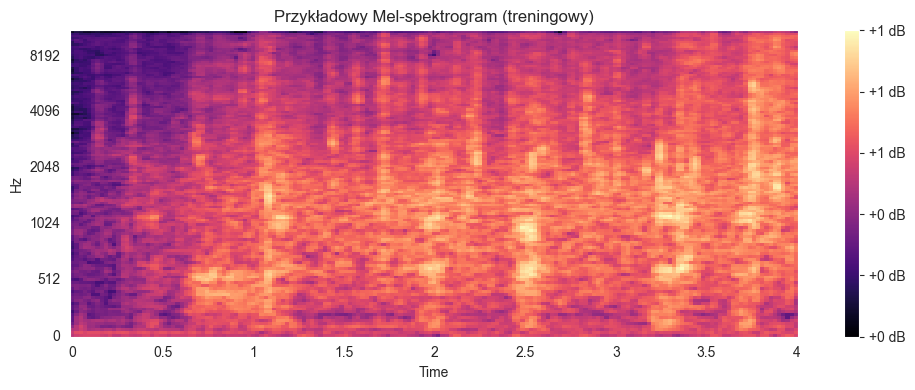

In [6]:
try:
    train_dataset = WildBoarDataset(
        dataframe=train_df, # Używamy DataFrame
        sample_rate=SAMPLE_RATE,
        duration=DURATION,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        augment=True, # Augmentacja dla zbioru treningowego
        filepath_col='FilePath', # Wskazujemy kolumnę zawierającą pełną ścieżkę
        label_col='Label' # Nazwa kolumny z etykietami
    )

    val_dataset = WildBoarDataset(
        dataframe=val_df, # Używamy DataFrame
        sample_rate=SAMPLE_RATE,
        duration=DURATION,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        augment=False, # Brak augmentacji dla zbioru walidacyjnego
        filepath_col='FilePath', # Wskazujemy kolumnę zawierającą pełną ścieżkę
        label_col='Label'
    )

    test_dataset = WildBoarDataset(
        dataframe=test_df, # Używamy DataFrame
        sample_rate=SAMPLE_RATE,
        duration=DURATION,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        augment=False, # Brak augmentacji dla zbioru testowego
        filepath_col='FilePath', # Wskazujemy kolumnę zawierającą pełną ścieżkę
        label_col='Label'
    )

    print("\nDataset'y zainicjalizowane pomyślnie!")
    print(f"Liczba próbek w train_dataset: {len(train_dataset)}")
    print(f"Liczba próbek w val_dataset: {len(val_dataset)}")
    print(f"Liczba próbek w test_dataset: {len(test_dataset)}")

    # Test Dataset - pobranie jednej próbki i wydruk jej kształtu
    if len(train_dataset) > 0:
        sample_mel_spec, sample_label = train_dataset[0]
        print(f"\nKształt Mel-spektrogramu (próbka treningowa): {sample_mel_spec.shape}") # Oczekiwany kształt: (1, N_MELS, num_frames)
        print(f"Etykieta próbki (treningowa): {sample_label}")

        # Wizualizacja przykładowego Mel-spektrogramu
        plt.figure(figsize=(10, 4))
        # .squeeze() usuwa wymiar kanału, żeby librosa.display.specshow mogło to zwizualizować
        librosa.display.specshow(sample_mel_spec.squeeze().numpy(),
                                 sr=SAMPLE_RATE, x_axis='time', y_axis='mel',
                                 hop_length=HOP_LENGTH, cmap='magma')
        plt.colorbar(format='%+2.0f dB')
        plt.title('Przykładowy Mel-spektrogram (treningowy)')
        plt.tight_layout()
        plt.show()
    else:
        print("\nBrak próbek w train_dataset do wizualizacji.")


except NameError as e:
    print(f"Błąd: Brak zdefiniowanych zmiennych lub DataFrame'ów (np. train_df, val_df, test_df, SAMPLE_RATE itp.). Upewnij się, że uruchomiłeś/aś wcześniejsze komórki generujące te obiekty: {e}")
except Exception as e:
    print(f"Wystąpił nieoczekiwany błąd podczas inicjalizacji datasetu lub ładowania próbki: {e}")
    print("Sprawdź, czy ścieżki w kolumnie 'FilePath' w Twoich DataFrame'ach są poprawne i czy pliki istnieją.")

In [7]:
import torch
from torch.utils.data import DataLoader

# --- Konfiguracja DataLoaderów ---
BATCH_SIZE = 32 # Możesz dostosować tę wartość w zależności od pamięci GPU
NUM_WORKERS = 0 # <-- ZMIEŃ TO NA 0, jeśli masz problemy na Windows/Jupyter!

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Mieszaj dane treningowe dla losowości i lepszego uogólnienia
    num_workers=NUM_WORKERS,
    # `persistent_workers` jest przydatne, gdy `num_workers > 0` i chcesz, aby procesy robocze
    # pozostały aktywne między epokami. W przypadku `num_workers=0`, ta opcja jest bez znaczenia.
    # Zostawiamy ją zakomentowaną lub usuwamy, jeśli num_workers jest 0.
    # persistent_workers=True if NUM_WORKERS > 0 else False
)

val_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Nie mieszaj danych walidacyjnych - spójna ocena
    num_workers=NUM_WORKERS,
    # persistent_workers=True if NUM_WORKERS > 0 else False
)


print(f"Używam num_workers: {NUM_WORKERS}")
print(f"Liczba batchy w train_loader: {len(train_loader)}")
print(f"Liczba batchy w val_loader: {len(val_loader)}")

# --- Testowanie DataLoaderów - pobieranie jednej paczki ---
# Ten blok kodu jest bezpieczny do uruchomienia bezpośrednio w Jupyterze,
# ponieważ `num_workers=0` (co oznacza, że ładowanie odbywa się w głównym procesie).
try:
    # Pobierz jedną paczkę z train_loader
    for mel_specs, labels in train_loader:
        print(f"\nKształt batcha Mel-spektrogramów (train_loader): {mel_specs.shape}") # Oczekiwane: (BATCH_SIZE, 1, N_MELS, num_frames)
        print(f"Kształt batcha etykiet (train_loader): {labels.shape}") # Oczekiwane: (BATCH_SIZE,)
        # Sprawdź typ danych i zakres (opcjonalnie, ale pomocne)
        print(f"Typ danych Mel-spektrogramów: {mel_specs.dtype}")
        print(f"Min/Max Mel-spektrogramów: {mel_specs.min():.2f} / {mel_specs.max():.2f}")
        print(f"Etykiety w batchu: {labels}")
        break # Pobierz tylko jeden batch do testowania
    print("Pomyślnie załadowano batch z train_loader!")

    # Pobierz jedną paczkę z val_loader
    for mel_specs_val, labels_val in val_loader:
        print(f"\nKształt batcha Mel-spektrogramów (val_loader): {mel_specs_val.shape}")
        print(f"Kształt batcha etykiet (val_loader): {labels_val.shape}")
        break
    print("Pomyślnie załadowano batch z val_loader!")

except Exception as e:
    print(f"\nBłąd podczas ładowania batcha z DataLoader: {e}")
    print("Sprawdź, czy `WildBoarDataset` poprawnie ładuje pliki i zwraca tensory.")
    print("Upewnij się, że pliki audio faktycznie istnieją w `AUDIO_DATA_DIR` i nazwy plików w DataFrame'ach są poprawne.")

Używam num_workers: 0
Liczba batchy w train_loader: 211
Liczba batchy w val_loader: 65

Kształt batcha Mel-spektrogramów (train_loader): torch.Size([32, 1, 128, 173])
Kształt batcha etykiet (train_loader): torch.Size([32])
Typ danych Mel-spektrogramów: torch.float32
Min/Max Mel-spektrogramów: 0.00 / 1.00
Etykiety w batchu: tensor([0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 1, 1, 0])
Pomyślnie załadowano batch z train_loader!

Kształt batcha Mel-spektrogramów (val_loader): torch.Size([32, 1, 128, 173])
Kształt batcha etykiet (val_loader): torch.Size([32])
Pomyślnie załadowano batch z val_loader!


In [8]:
'''import torch

print("Rozpoczynam pełną weryfikację spójności wymiarów Mel-spektrogramów w train_loader...")

unique_mel_spec_shapes = set()
invalid_samples_count = 0

for i, (mel_specs, labels) in enumerate(train_loader):
    if labels.dim() == 0 and labels == -1: # Sprawdzamy, czy to uszkodzona próbka
        invalid_samples_count += mel_specs.size(0) # Liczymy cały batch, jeśli jakiś błąd w ładowaniu
        print(f"Ostrzeżenie: Wykryto uszkodzone próbki w batchu {i}. Ładuję dalej...")
        continue # Pomijamy analizę kształtu dla uszkodzonych batchy

    # mel_specs.shape to (BATCH_SIZE, CHANNELS, N_MELS, num_frames)
    # Dodajemy kształt pojedynczej próbki do zbioru unikalnych kształtów
    # Pomijamy wymiar batcha (mel_specs.shape[0])
    current_sample_shape = tuple(mel_specs.shape[1:])
    unique_mel_spec_shapes.add(current_sample_shape)

print(f"\n--- Wyniki weryfikacji ---")
print(f"Unikalne pełne kształty Mel-spektrogramów w train_loader: {unique_mel_spec_shapes}")

if invalid_samples_count > 0:
    print(f"Liczba próbek z błędami ładowania (etykieta -1): {invalid_samples_count}")

if len(unique_mel_spec_shapes) == 1:
    print(f"Weryfikacja zakończona sukcesem: Wszystkie Mel-spektrogramy mają identyczny kształt: {list(unique_mel_spec_shapes)[0]}.")
else:
    print(f"BŁĄD WERYFIKACJI: Wykryto {len(unique_mel_spec_shapes)} różnych kształtów Mel-spektrogramów!")
    print("Model wymaga, aby wszystkie wejścia miały identyczne wymiary.")
    print("Sprawdź swoją klasę WildBoarDataset, szczególnie kroki związane z paddingiem/przycinaniem sygnału audio oraz generowaniem cech (Mel, Delta).")
    raise ValueError("Mel-spectrograms have inconsistent dimensions!")

print("-" * 50)'''

'import torch\n\nprint("Rozpoczynam pełną weryfikację spójności wymiarów Mel-spektrogramów w train_loader...")\n\nunique_mel_spec_shapes = set()\ninvalid_samples_count = 0\n\nfor i, (mel_specs, labels) in enumerate(train_loader):\n    if labels.dim() == 0 and labels == -1: # Sprawdzamy, czy to uszkodzona próbka\n        invalid_samples_count += mel_specs.size(0) # Liczymy cały batch, jeśli jakiś błąd w ładowaniu\n        print(f"Ostrzeżenie: Wykryto uszkodzone próbki w batchu {i}. Ładuję dalej...")\n        continue # Pomijamy analizę kształtu dla uszkodzonych batchy\n\n    # mel_specs.shape to (BATCH_SIZE, CHANNELS, N_MELS, num_frames)\n    # Dodajemy kształt pojedynczej próbki do zbioru unikalnych kształtów\n    # Pomijamy wymiar batcha (mel_specs.shape[0])\n    current_sample_shape = tuple(mel_specs.shape[1:])\n    unique_mel_spec_shapes.add(current_sample_shape)\n\nprint(f"\n--- Wyniki weryfikacji ---")\nprint(f"Unikalne pełne kształty Mel-spektrogramów w train_loader: {unique_mel_

In [9]:
def calculate_num_frames(sample_rate, duration, n_fft, hop_length):
    total_samples = sample_rate * duration
    return 1 + (total_samples - n_fft) // hop_length

INPUT_MEL_HEIGHT = 128
INPUT_MEL_WIDTH = 173

class AudioClassifier(nn.Module):
    def __init__(self, num_classes, input_height, input_width, dropout=0.5, dropout2d=0.25):
        super(AudioClassifier, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=(5, 3), padding=(2, 1))
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2)) # Zmniejsza wymiary o połowę
        self.dropout2d_conv = nn.Dropout2d(dropout2d)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3, 3), padding=(1, 1))
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2)) # Zmniejsza wymiary o połowę

        final_height_after_pooling = input_height // 4
        final_width_after_pooling = input_width // 4

        self.flattened_features = 128 * final_height_after_pooling * final_width_after_pooling
        self.fc1 = nn.Linear(self.flattened_features, 512)
        self.dropout_fc = nn.Dropout(dropout2d)
        self.fc2 = nn.Linear(512, num_classes) # num_classes to 2 (dzik/brak dzika)

    def forward(self, x):
        # x shape: (Batch_size, 1, input_height, input_width)
        # Warstwa 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.dropout2d_conv(x)

        # Warstwa 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.dropout2d_conv(x)

        # Spłaszczenie dla warstw w pełni połączonych
        x = x.view(x.size(0), -1) # -1 automatycznie oblicza wszystkie pozostałe wymiary

        # Warstwy w pełni połączone
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x) # Ponowne zastosowanie dropoutu
        x = self.fc2(x) # Ostatnia warstwa bez aktywacji (dla funkcji straty CrossEntropyLoss)
        return x

In [10]:
# Sprawdzenie dostępności GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
from torch.optim.lr_scheduler import ReduceLROnPlateau # <-- DODAJ TEN IMPORT


# --- Parametry treningu ---
NUM_EPOCHS = 30       # Liczba epok treningowych
NUM_CLASSES = 2        # Liczba klas: 0 (brak dzika), 1 (dzik)

LEARNING_RATE = 0.001  # Szybkość uczenia optymalizatora
DROPOUT = 0.75
DROPOUT_2D = 0.4
WEIGHT_DECAY = 1e-3


INPUT_MEL_HEIGHT = 128
INPUT_MEL_WIDTH = 173 # Ta wartość powinna pochodzić z Twoich obliczeń num_frames

model = AudioClassifier(num_classes=NUM_CLASSES, input_height=INPUT_MEL_HEIGHT, input_width=INPUT_MEL_WIDTH, dropout=DROPOUT, dropout2d=DROPOUT_2D).to(device)
model.to(device) # Przeniesienie modelu na wybrane urządzenie (GPU/CPU)

criterion = nn.CrossEntropyLoss() # Standardowa funkcja straty dla problemów klasyfikacji wieloklasowej
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)



In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    print("\nStarting training...")
    history = {
        'train_loss': [], 'val_loss': [],
        'train_accuracy': [], 'val_accuracy': [],
        'learning_rate': [],
        'train_probs_history': [], 'train_labels_history': [], # Dodane do zbierania danych do ROC
        'val_probs_history': [], 'val_labels_history': []      # Dodane do zbierania danych do ROC
    }
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, min_lr=1e-6)

    #  Zapisz najlepszy model
    best_val_accuracy = 0.0
    best_model_path = 'best_audio_classifier_model_q0files_1st_scheduler.pth'

    for epoch in range(num_epochs):
        start_time = time.time() # Start pomiaru czasu dla epoki

        # --- Faza Treningowa ---
        model.train() # Ustawienie modelu w tryb treningowy
        running_loss = 0.0
        all_train_preds = []
        all_train_labels = []
        all_train_probs_epoch = []

        for batch_idx, (mel_specs, labels) in enumerate(train_loader):
            mel_specs = mel_specs.to(device)
            labels = labels.to(device)

            # Zerowanie gradientów
            optimizer.zero_grad()

            # Forward pass
            outputs = model(mel_specs)

            # Obliczenie straty
            loss = criterion(outputs, labels)

            # Backward pass i optymalizacja
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * mel_specs.size(0)

            # Zbieranie predykcji do obliczenia dokładności
            _, predicted = torch.max(outputs.data, 1)
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

            # Pobranie prawdopodobieństw dla klasy pozytywnej (indeks 1)
            # F.softmax przekształca logity na prawdopodobieństwa
            probs = F.softmax(outputs, dim=1)[:, 1]
            all_train_probs_epoch.extend(probs.detach().cpu().numpy())

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = accuracy_score(all_train_labels, all_train_preds)
        history['train_loss'].append(epoch_train_loss)
        history['train_accuracy'].append(epoch_train_accuracy)
        history['train_probs_history'].append(all_train_probs_epoch) # Zapisujemy prawdopodobieństwa epoki
        history['train_labels_history'].append(all_train_labels)     # Zapisujemy etykiety epoki


        # --- Faza Walidacyjna ---
        model.eval() # Ustawienie modelu w tryb ewaluacji
        val_running_loss = 0.0
        all_val_preds = []
        all_val_labels = []
        all_val_probs_epoch = []

        with torch.no_grad(): # Wyłączenie obliczania gradientów dla walidacji
            for mel_specs, labels in val_loader:
                mel_specs = mel_specs.to(device)
                labels = labels.to(device)

                outputs = model(mel_specs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * mel_specs.size(0)

                _, predicted = torch.max(outputs.data, 1)
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

                probs = F.softmax(outputs, dim=1)[:, 1]
                all_val_probs_epoch.extend(probs.detach().cpu().numpy())

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_accuracy = accuracy_score(all_val_labels, all_val_preds)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_accuracy)
        history['val_probs_history'].append(all_val_probs_epoch) # Zapisujemy prawdopodobieństwa epoki
        history['val_labels_history'].append(all_val_labels)     # Zapisujemy etykiety epoki

        # --- Krok Schedulera ---
        scheduler.step(epoch_val_loss)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])

        end_time = time.time() # Koniec pomiaru czasu dla epoki
        epoch_duration = end_time - start_time # Obliczenie czasu trwania epoki

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
              f"Current LR: {optimizer.param_groups[0]['lr']:.6f} | " # Dodano wyświetlanie LR
              f"Time: {epoch_duration:.2f}s")

        # Zapisz model, jeśli poprawiła się dokładność walidacji
        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy
            best_model_path = f'val_acc_{best_val_accuracy:.4f}.pth'
            torch.save(model.state_dict(), best_model_path)
            print(f"Model saved! Best Val Acc: {best_val_accuracy:.4f} (Epoch {epoch+1})")

    print("\nTraining complete!")
    print(f"Best model saved to: {best_model_path}")
    return history, best_model_path

In [13]:
NUM_EPOCHS = 5
#model = model.load_state_dict(torch.load(best_audio_classifier_model_augmentation_dropout_0.5.pth))
training_history, best_model_path = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, device)


Starting training...
Epoch 1/5: Train Loss: 3.6628, Train Acc: 0.7546 | Val Loss: 0.6878, Val Acc: 0.5224 | Current LR: 0.001000 | Time: 619.43s
Model saved! Best Val Acc: 0.5224 (Epoch 1)
Epoch 2/5: Train Loss: 0.3658, Train Acc: 0.8311 | Val Loss: 0.5767, Val Acc: 0.6267 | Current LR: 0.001000 | Time: 617.55s
Model saved! Best Val Acc: 0.6267 (Epoch 2)
Epoch 3/5: Train Loss: 0.3063, Train Acc: 0.8630 | Val Loss: 0.6411, Val Acc: 0.6960 | Current LR: 0.001000 | Time: 619.76s
Model saved! Best Val Acc: 0.6960 (Epoch 3)
Epoch 4/5: Train Loss: 0.2827, Train Acc: 0.8732 | Val Loss: 0.5311, Val Acc: 0.8095 | Current LR: 0.001000 | Time: 614.90s
Model saved! Best Val Acc: 0.8095 (Epoch 4)
Epoch 5/5: Train Loss: 0.2690, Train Acc: 0.8820 | Val Loss: 0.9023, Val Acc: 0.6772 | Current LR: 0.001000 | Time: 614.36s

Training complete!
Best model saved to: val_acc_0.8095.pth


In [14]:
def plot_training_history(history):
    """
    Wyświetla wykresy straty, dokładności i Learning Rate z historii treningu.

    Args:
        history (dict): Słownik zawierający historię treningu,
                        zazwyczaj zwracany przez funkcję train_model.
                        Powinien zawierać klucze:
                        'train_loss', 'val_loss', 'train_accuracy', 'val_accuracy', 'learning_rate'.
    """

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 5)) # Zwiększamy rozmiar figury dla lepszej czytelności

    # --- Wykres Straty (Loss) ---
    plt.subplot(1, 3, 1) # 1 rząd, 3 kolumny, pierwszy wykres
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o', markersize=4)
    plt.plot(epochs, history['val_loss'], label='Val Loss', marker='x', markersize=4)
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # --- Wykres Dokładności (Accuracy) ---
    plt.subplot(1, 3, 2) # 1 rząd, 3 kolumny, drugi wykres
    plt.plot(epochs, history['train_accuracy'], label='Train Accuracy', marker='o', markersize=4)
    plt.plot(epochs, history['val_accuracy'], label='Val Accuracy', marker='x', markersize=4)
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()

    # --- Wykres Learning Rate ---
    plt.subplot(1, 3, 3) # 1 rząd, 3 kolumny, trzeci wykres
    plt.plot(epochs, history['learning_rate'], label='Learning Rate', marker='o', markersize=4, color='green')
    plt.title('Learning Rate over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.legend()
    plt.yscale('log') # Użyj skali logarytmicznej, bo LR często zmienia się o rzędy wielkości

    plt.tight_layout() # Dopasuj układ, aby etykiety się nie nakładały
    plt.show() # Wyświetl wykresy

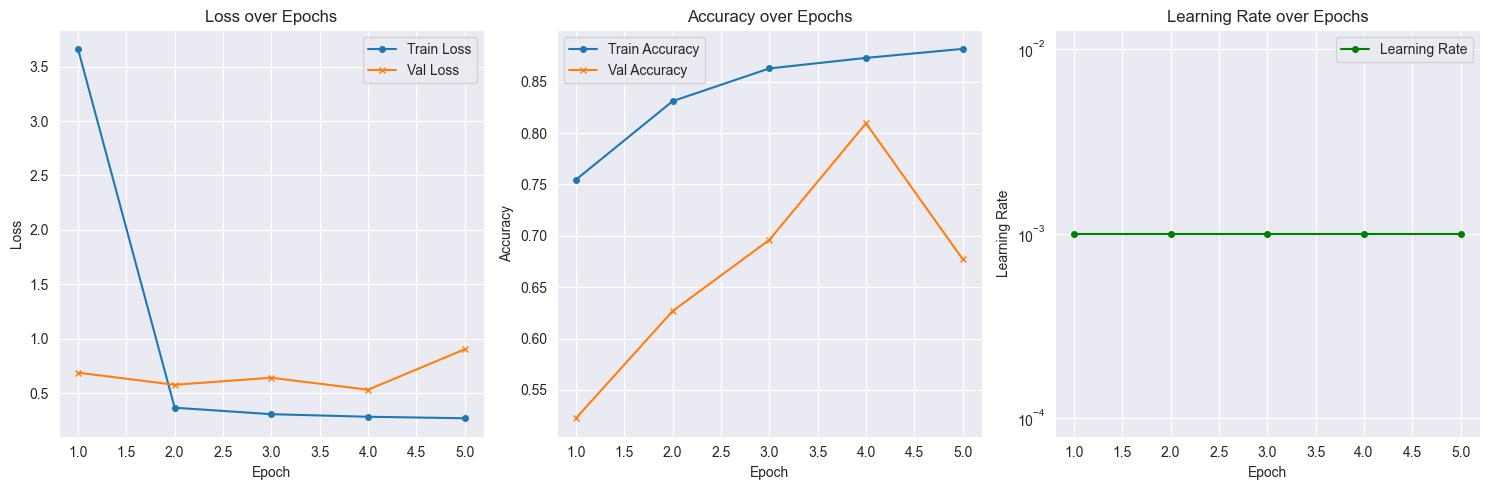

In [15]:
plot_training_history(training_history)

In [16]:
#best_model_path = 'val_acc_0.8110.pth'
#'best_audio_classifier_model.pth'

In [21]:
#best_model_path = "best_audio_classifier_model.pth"
model.load_state_dict(torch.load(best_model_path))
model.eval() # Ustaw model w tryb ewaluacji


AudioClassifier(
  (conv1): Conv2d(1, 64, kernel_size=(5, 3), stride=(1, 1), padding=(2, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout2d_conv): Dropout2d(p=0.4, inplace=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=176128, out_features=512, bias=True)
  (dropout_fc): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)

In [22]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model_on_test_set(model, test_loader, criterion, device, best_model_path):
    """
    Ocenia wytrenowany model na zbiorze testowym, wyświetla metryki i wizualizacje
    dla klasyfikacji binarnej.

    Args:
        model (torch.nn.Module): Wytrenowany model PyTorch.
        test_loader (torch.utils.data.DataLoader): DataLoader dla zbioru testowego.
        criterion (torch.nn.Module): Funkcja straty (np. nn.CrossEntropyLoss).
        device (torch.device): Urządzenie, na którym ma być przeprowadzona ocena ('cpu' lub 'cuda').

    Returns:
        dict: Słownik zawierający metryki testowe (loss, accuracy, f1, precision, recall, confusion_matrix).
    """
    model.to(device) # Upewnij się, że model jest na odpowiednim urządzeniu

    all_test_preds = []
    all_test_probs = []
    all_test_labels = []
    test_running_loss = 0.0

    with torch.no_grad(): # Wyłącz obliczanie gradientów dla oceny
        for mel_specs, labels in test_loader:
            mel_specs = mel_specs.to(device)
            labels = labels.to(device)
            outputs = model(mel_specs)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item() * mel_specs.size(0)
            # Przewidywanie klas
            _, predicted = torch.max(outputs.data, 1)
            all_test_preds.extend(predicted.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())

            probs = F.softmax(outputs, dim=1)[:, 1]
            # POPRAWKA TUTAJ: dodaj .detach()
            all_test_probs.extend(probs.detach().cpu().numpy())



    test_loss = test_running_loss / len(test_loader.dataset)
    # Obliczanie metryk
    test_accuracy = accuracy_score(all_test_labels, all_test_preds)
    # Dla klasyfikacji binarnej 'average='binary'' jest zazwyczaj odpowiednie
    test_f1 = f1_score(all_test_labels, all_test_preds, average='binary')
    test_precision = precision_score(all_test_labels, all_test_preds, average='binary')
    test_recall = recall_score(all_test_labels, all_test_preds, average='binary')
    cm = confusion_matrix(all_test_labels, all_test_preds)

    print(f"\n--- Final Model Test Results ---")
    print(f"  Loss: {test_loss:.4f}")
    print(f"  Accuracy: {test_accuracy:.4f}")
    print(f"  F1 Score: {test_f1:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall: {test_recall:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    # --- Wizualizacja Macierzy Pomyłek ---
    # Upewnij się, że Twoje etykiety to 0 i 1 (lub masz mapowanie nazw klas)
    # Przyjmujemy, że 0 to klasa negatywna, 1 to klasa pozytywna
    class_names = ['Negative', 'Positive'] # Dostosuj nazwy klas, jeśli masz inne
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title('Confusion Matrix on Test Set')
    plt.show()

    # --- Opcjonalna wizualizacja ROC AUC (wymaga prob predykcji, której tu nie mamy) ---
    # Jeśli chciałbyś dodać krzywą ROC, musiałbyś zbierać logits lub prawdopodobieństwa
    # z modelu dla zbioru testowego i użyć sklearn.metrics.roc_curve oraz roc_auc_score.
    # Wymagałoby to zmiany w pętli oceny: outputs = model(mel_specs) -> probabilities = F.softmax(outputs, dim=1)[:, 1]
    # all_test_probs.extend(probabilities.cpu().numpy())
    # i potem roc_curve(all_test_labels, all_test_probs), roc_auc_score(all_test_labels, all_test_probs)

    test_results = {
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'test_f1': test_f1,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'confusion_matrix': cm.tolist() # Konwertuj na listę, aby słownik był bardziej przenośny
    }

    return test_results

In [23]:
test_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Rozmiar zbioru testowego: {len(test_dataset)}")
print(f"Liczba batchy w loaderze testowym: {len(test_loader)}")

Rozmiar zbioru testowego: 2079
Liczba batchy w loaderze testowym: 63



--- Final Model Test Results ---
  Loss: 0.8646
  Accuracy: 0.6210
  F1 Score: 0.6864
  Precision: 0.5454
  Recall: 0.9257
  Confusion Matrix:
[[415 696]
 [ 67 835]]


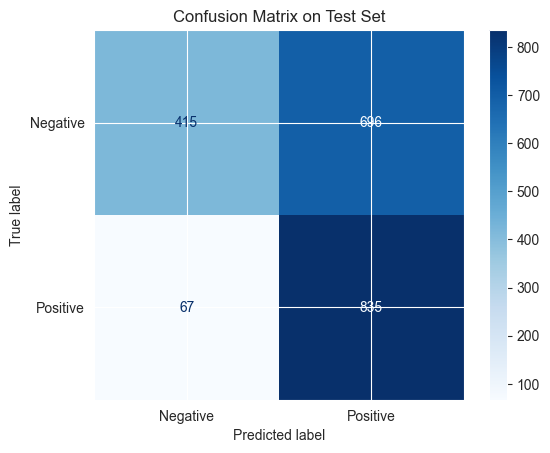


Test metrics dictionary: {'test_loss': 0.8645581179632728, 'test_accuracy': 0.620963735717834, 'test_f1': 0.6863953966296753, 'test_precision': 0.5453951665578054, 'test_recall': 0.9257206208425721, 'confusion_matrix': [[415, 696], [67, 835]]}


In [24]:
# Wywołaj funkcję oceny
test_metrics = evaluate_model_on_test_set(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    best_model_path=best_model_path
)

print("\nTest metrics dictionary:", test_metrics)
